In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math

Encontré 7 archivos


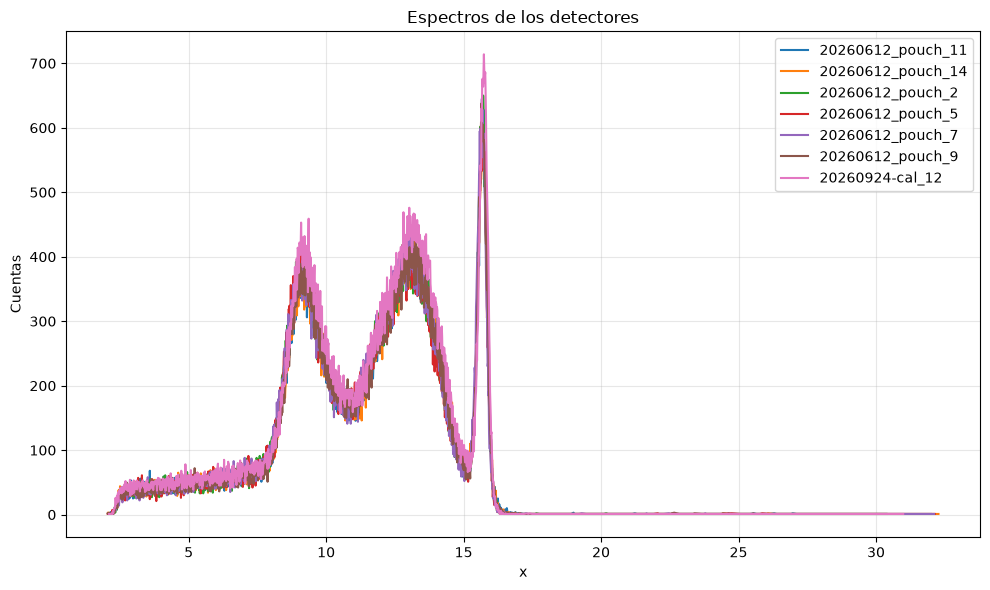

In [5]:
carpeta = Path(r"..\espectros-detectores")

archivos = sorted(carpeta.rglob("*_spectrum.csv"))

print("Encontré", len(archivos), "archivos")

plt.figure(figsize=(10, 6))

for archivo in archivos:

    datos = pd.read_csv(archivo)

    nombre = archivo.stem.replace("_ch1_spectrum", "")

    plt.plot(
        datos["x"],
        datos["y"],
        label=nombre
    )

plt.xlabel("x")
plt.ylabel("Cuentas")
plt.title("Espectros de los detectores")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

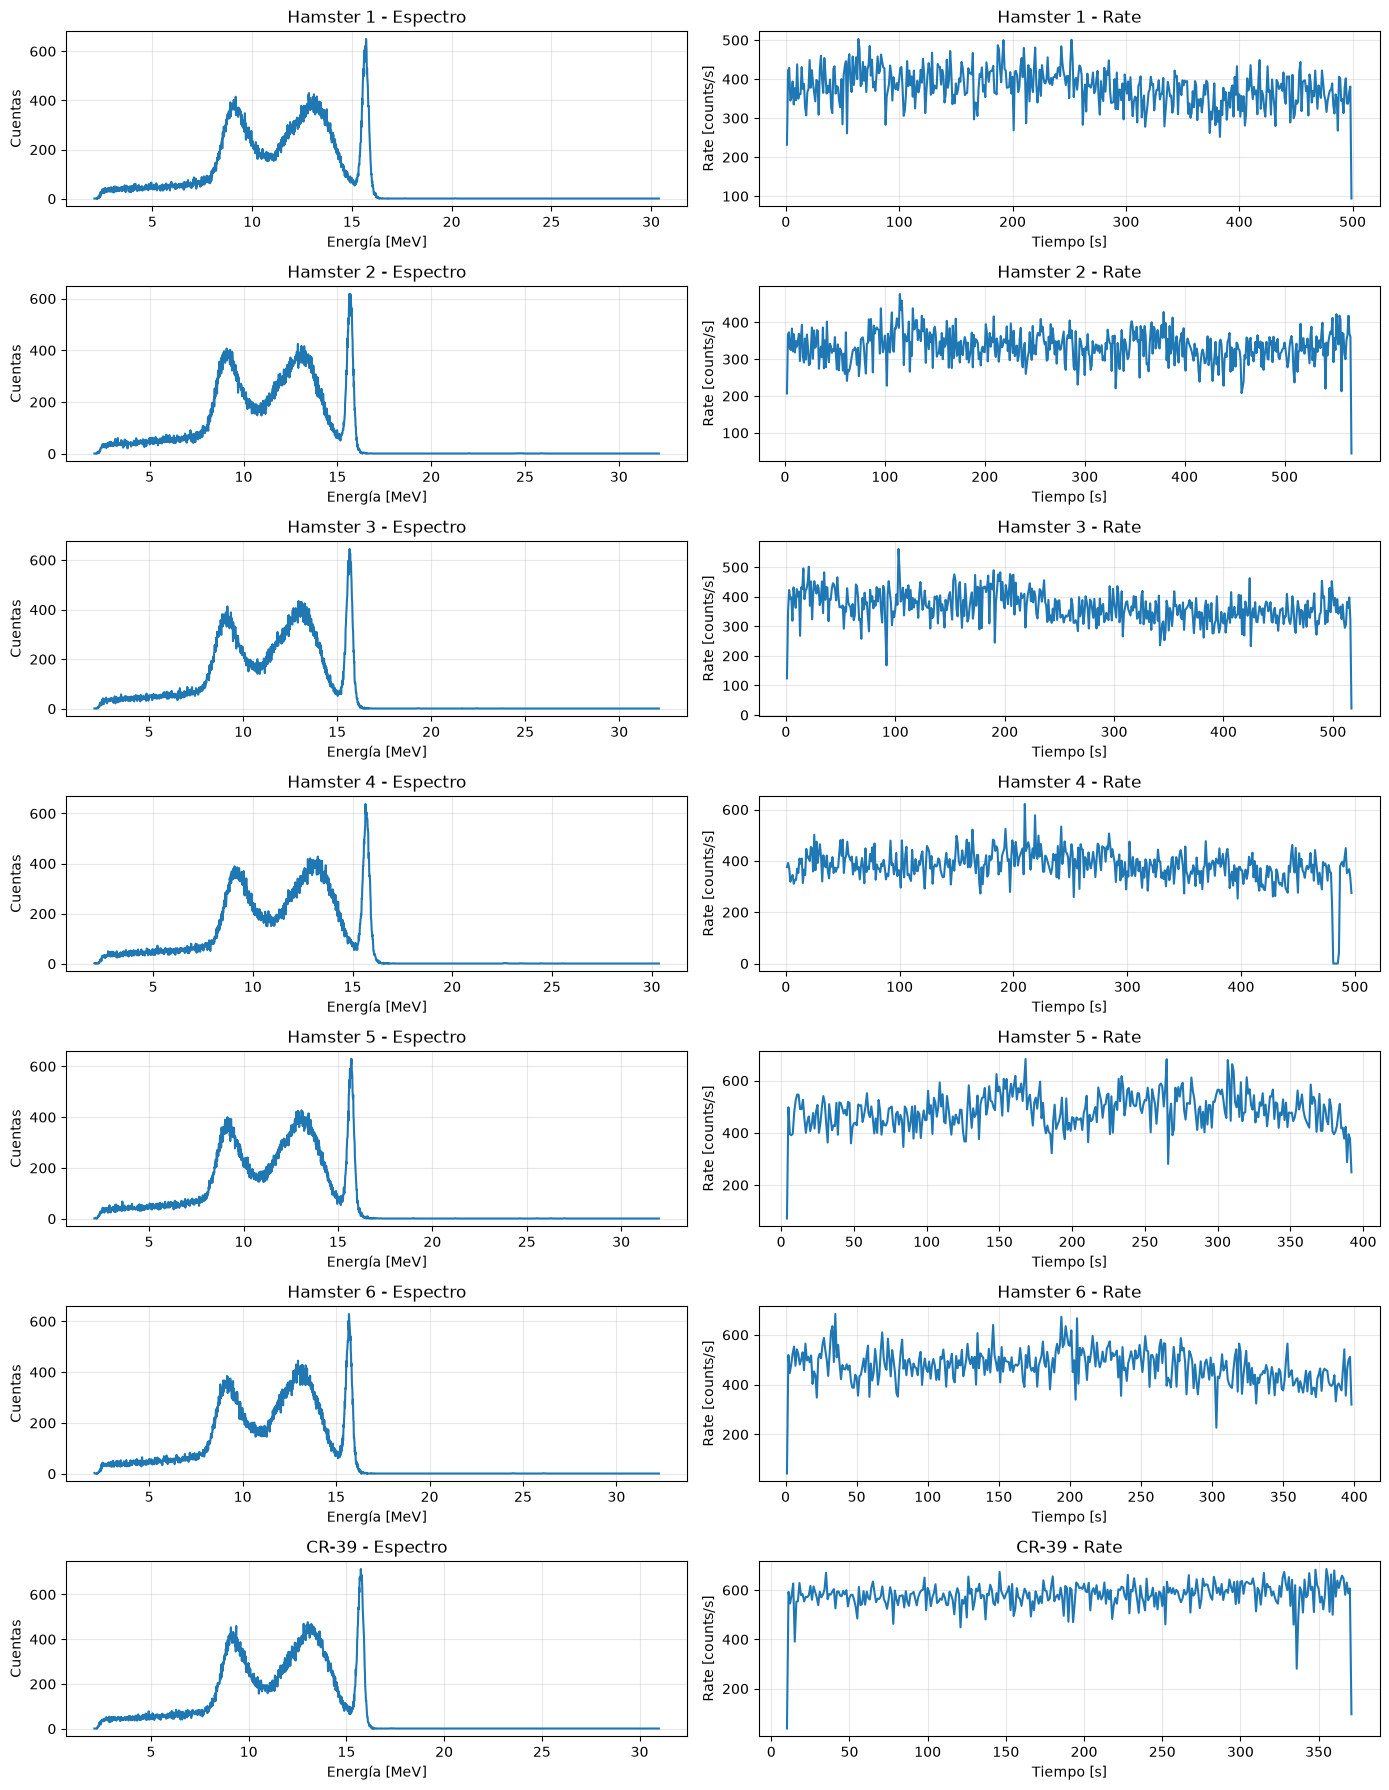

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

carpeta = Path(r"..\espectros-detectores")

archivos = [
    ("20260612_pouch_2", "Hamster 1"),
    ("20260612_pouch_5", "Hamster 2"),
    ("20260612_pouch_7", "Hamster 3"),
    ("20260612_pouch_9", "Hamster 4"),
    ("20260612_pouch_11", "Hamster 5"),
    ("20260612_pouch_14", "Hamster 6"),
    ("20260924-cal_12", "CR-39")
]

fig, axs = plt.subplots(len(archivos), 2, figsize=(14, 18))

for i, (nombre_archivo, nombre_grafico) in enumerate(archivos):

    espectro = pd.read_csv(
        carpeta / f"{nombre_archivo}_ch1_spectrum.csv"
    )

    rate = pd.read_csv(
        carpeta / f"{nombre_archivo}_ch1_rate.csv"
    )

    axs[i, 0].plot(espectro["x"], espectro["y"])
    axs[i, 0].set_title(f"{nombre_grafico} - Espectro")
    axs[i, 0].set_xlabel("Energía [MeV]")
    axs[i, 0].set_ylabel("Cuentas")
    axs[i, 0].grid(alpha=0.3)

    axs[i, 1].plot(rate["x"], rate["y"])
    axs[i, 1].set_title(f"{nombre_grafico} - Rate")
    axs[i, 1].set_xlabel("Tiempo [s]")
    axs[i, 1].set_ylabel("Rate [counts/s]")
    axs[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()